In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("covid_india.csv")
df['Date'] = pd.to_datetime(df['Date'])

In [3]:
print(df.head())

        Date  Confirmed  Recovered  Deaths
0 2020-03-01        235        214      15
1 2020-03-02        530        282      40
2 2020-03-03        704        534      76
3 2020-03-04       1021        747      87
4 2020-03-05       1201        954     102


In [8]:
df['New_Confirmed'] = df['Confirmed'].diff().fillna(0)
df['New_Recovered'] = df['Recovered'].diff().fillna(0)
df['New_Deaths'] = df['Deaths'].diff().fillna(0)

In [9]:
df['Recovery_Rate (%)'] = (df['Recovered'] / df['Confirmed']) * 100
df['Death_Rate (%)'] = (df['Deaths'] / df['Confirmed']) * 100

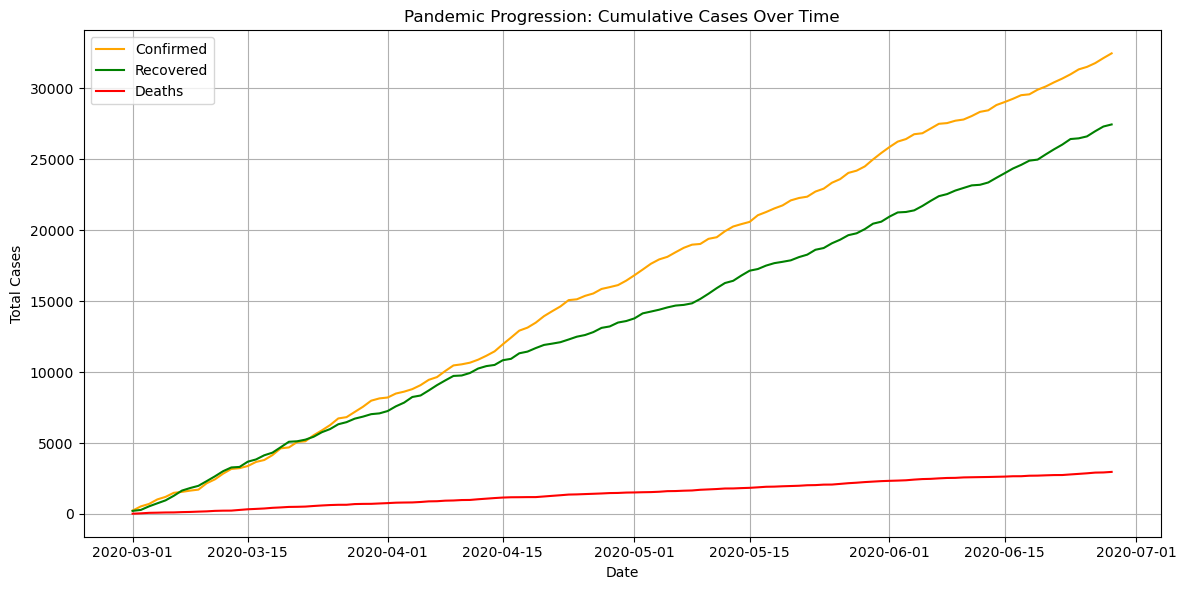

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Confirmed'], label='Confirmed', color='orange')
plt.plot(df['Date'], df['Recovered'], label='Recovered', color='green')
plt.plot(df['Date'], df['Deaths'], label='Deaths', color='red')
plt.title("Pandemic Progression: Cumulative Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Total Cases")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

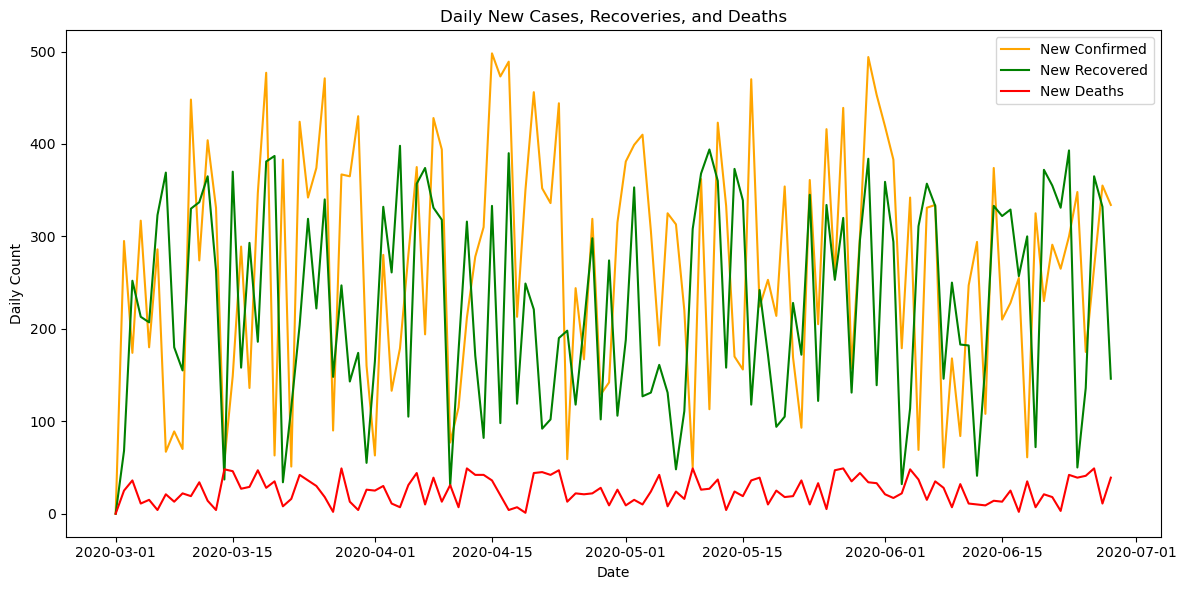

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['New_Confirmed'], label='New Confirmed', color='orange')
plt.plot(df['Date'], df['New_Recovered'], label='New Recovered', color='green')
plt.plot(df['Date'], df['New_Deaths'], label='New Deaths', color='red')
plt.title("Daily New Cases, Recoveries, and Deaths")
plt.xlabel("Date")
plt.ylabel("Daily Count")
plt.legend()
plt.tight_layout()
plt.show()

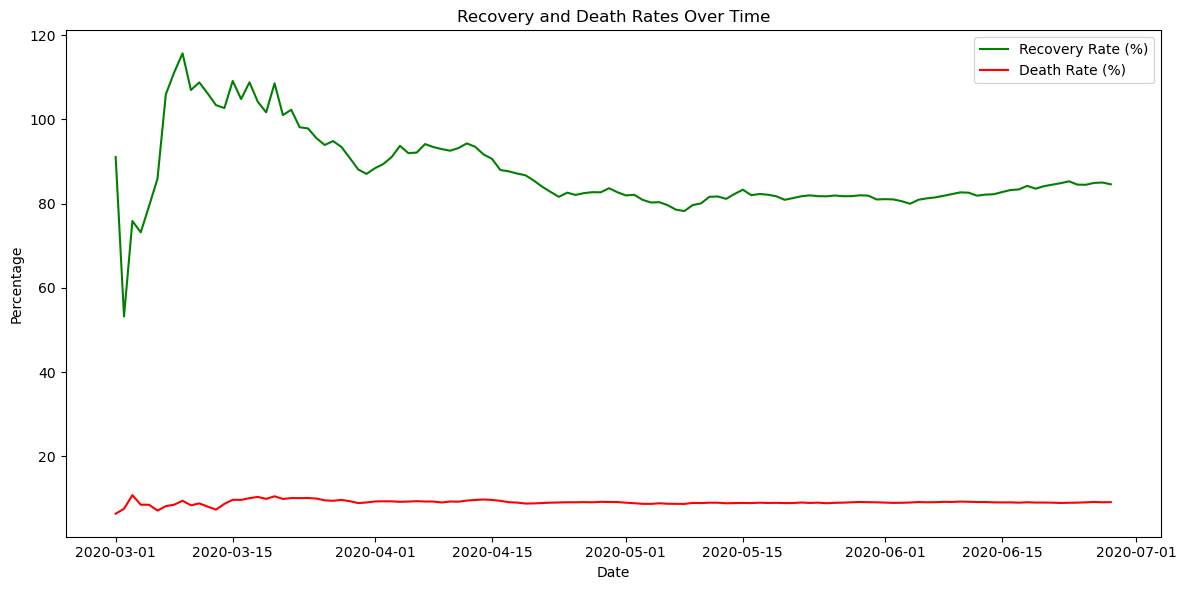

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Recovery_Rate (%)'], label='Recovery Rate (%)', color='green')
plt.plot(df['Date'], df['Death_Rate (%)'], label='Death Rate (%)', color='red')
plt.title("Recovery and Death Rates Over Time")
plt.xlabel("Date")
plt.ylabel("Percentage")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
latest = df.iloc[-1]
print("Pandemic Summary Report:")
print(f"Total Confirmed Cases : {int(latest['Confirmed'])}")
print(f"Total Recoveries      : {int(latest['Recovered'])}")
print(f"Total Deaths          : {int(latest['Deaths'])}")
print(f"Recovery Rate (%)     : {latest['Recovery_Rate (%)']:.2f}%")
print(f"Death Rate (%)        : {latest['Death_Rate (%)']:.2f}%")

Pandemic Summary Report:
Total Confirmed Cases : 32475
Total Recoveries      : 27462
Total Deaths          : 2963
Recovery Rate (%)     : 84.56%
Death Rate (%)        : 9.12%
